
# NLP Final Project – Maintenance Work Order Analysis

## Project Overview
This notebook explores maintenance work order data and builds baseline NLP models.

Goals:
- Clean and understand the dataset
- Compare **pre-2020 vs post-2020** work orders
- Build a **baseline classification model (trade prediction)**
- Explore cost trends
This follows the proposal:
- classify trade
- predict cost
- detect patterns


# Environment Setup

## Overview

This project was developed in **Python** using **Jupyter Notebook** and applies Natural Language Processing (NLP) techniques to maintenance work order data.

The notebook performs:
- Text preprocessing (cleaning, tokenization, TF-IDF)
- Classification (trade prediction)
- Regression (cost prediction)
- Visualization and error analysis

⚠️ **Important:**  
The dataset is **NOT included in this repository** because the CSV files are too large for GitHub. You must download them manually (see Step 4).

## 1. Clone the repository

    git clone https://github.com/CheikhLame/NLP_Project.git
    cd NLP_Project

## 2. Set up environment and install required packages

It is recommended to install the project dependencies in a clean Python environment to avoid conflicts with other packages on your system.

### Create a new environment

**macOS / Linux**

    python3 -m venv env
    source env/bin/activate

**Windows**

    python -m venv env
    env\Scripts\activate

### Install project dependencies

Once the environment is activated, install all required packages using the provided `requirements.txt` file:

    pip install -r requirements.txt

This will install all necessary libraries (pandas, numpy, matplotlib, scikit-learn, seaborn, jupyter, etc.) needed to run the notebook.

## 3. Required Python imports (used in notebook)

The notebook uses the following libraries:

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import re

    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report

    # Additional models and utilities
    from sklearn.metrics import confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error
    from sklearn.svm import LinearSVC
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.pipeline import Pipeline

All of these are installed via `requirements.txt`.

## 4. Download dataset (REQUIRED)

Download the dataset from Google Drive:

👉 https://drive.google.com/drive/folders/1dnkfpswJ1R24usBbbxReb3GMPbCEFKnL?usp=drive_link

After downloading, place the CSV files in the same directory as the notebook (`.ipynb`).

## 5. Expected project structure

    NLP_Project/
    ├── nlp_final_project_baseline_ordered.ipynb
    ├── NLP Report 2002-2009.csv
    ├── NLP Report 2010-2019.csv
    ├── NLP Report.csv
    ├── README.md
    ├── requirements.txt
    └── ...

If the CSV files are missing or placed elsewhere, the notebook will not run correctly.

## 6. Launch Jupyter Notebook

    jupyter notebook

Then open the `.ipynb` file and run all cells from top to bottom.

(Optional)

    jupyter lab

## 7. How to run correctly

- Install dependencies using `requirements.txt`  
- Confirm CSV files are in the correct directory  
- Open Jupyter Notebook  
- Run cells in order  
- Restart kernel and rerun if errors occur  

## 8. Common issues and fixes

❌ **FileNotFoundError**  
Cause: CSV files not found  
Fix: Ensure CSVs are in the same folder as the notebook  

❌ **ModuleNotFoundError**  
Cause: Missing package  
Fix:

    pip install -r requirements.txt

❌ **Weird errors / inconsistent results**  
Cause: Cells run out of order or stale variables  
Fix: Restart kernel and run all cells from the top  

❌ **Wrong Python being used**  
Fix:

    which python     # macOS/Linux
    where python     # Windows

Make sure it points to your expected Python installation.

## ✅ Summary

- Clone the repository  
- Install dependencies using `requirements.txt`  
- Download dataset from Google Drive  
- Place CSV files next to the notebook  
- Launch Jupyter Notebook  
- Run all cells in order  

If everything is set up correctly, the notebook should run without errors.

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


## Load Data

In [5]:
# -----------------------------
# File paths
# -----------------------------
files = [
    "NLP Report 2002-2009.csv",
    "NLP Report 2010-2019.csv",
    "NLP Report.csv",
]

# -----------------------------
# Helper: load one raw export correctly
# -----------------------------
def load_workorder_export(path, encoding="latin1"):
    """
    Loads a Boise State maintenance export where:
    row 0 = export timestamp
    row 1 = report title
    row 2 = blank
    row 3 = actual header row
    row 4+ = data
    """
    raw = pd.read_csv(path, header=None, encoding=encoding, low_memory=False)

    # Real header is row index 3
    header = raw.iloc[3, :11].tolist()

    # Data begins after header
    df = raw.iloc[4:, :11].copy()
    df.columns = header
    df.reset_index(drop=True, inplace=True)

    return df

# -----------------------------
# Load all files
# -----------------------------
dfs = []
for f in files:
    df_part = load_workorder_export(f)
    df_part["source_file"] = f
    dfs.append(df_part)

data = pd.concat(dfs, ignore_index=True)

print("Combined shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())


Combined shape: (316979, 12)

Columns:
['Request', 'Building Name', 'Request Date', 'Completion Date', 'Priority Code', 'Priority Description', 'Trade Description', 'Total Hours', 'Total Labor Cost', 'Total Material Cost', 'Total Other Cost', 'source_file']


## Fix Columns

In [6]:
rename_map = {
    "Request": "request_text",
    "Building Name": "building_name",
    "Request Date": "request_date",
    "Completion Date": "completion_date",
    "Priority Code": "priority_code",
    "Priority Description": "priority_description",
    "Trade Description": "trade_description",
    "Total Hours": "total_hours",
    "Total Labor Cost": "total_labor_cost",
    "Total Material Cost": "total_material_cost",
    "Total Other Cost": "total_other_cost",
}

data = data.rename(columns=rename_map)

display(data.head())
print(data.columns.tolist())

,request_text,building_name,request_date,completion_date,priority_code,priority_description,trade_description,total_hours,total_labor_cost,total_material_cost,total_other_cost,source_file
0,"RM 131, 132, 133, 134 TO COLD - Test DB...",Chrisway Annex,10/31/2002,11/04/2002 07:00,1,Routine,HVAC,1.25,$56.25,$0.00,$0.00,NLP Report 2002-2009.csv
1,Closed per Foreman. - Closed per Foreman. - No...,Boulder Hall,10/31/2002,12/16/2017 17:00,1,Routine,Electrician,0.5,$13.80,$0.00,$0.00,NLP Report 2002-2009.csv
2,"Reset fire alarm at fire alarm panel, inside ...",Engineering (RUCH),10/31/2002,12/03/2002 11:12,1,Routine,Electrician,6.25,$172.50,$0.00,"$1,937.30",NLP Report 2002-2009.csv
3,Freezer is not cold.\n\nLA radioed / ml,Copper Basin,10/31/2002,11/15/2002 06:48,1,Routine,HVAC,0.25,$6.63,$0.00,$0.00,NLP Report 2002-2009.csv
4,No air flow.\n\nLarel radioed / ml\nFans down ...,Riverfront Hall,10/31/2002,11/18/2002 07:00,1,Routine,HVAC,0.25,$6.63,$0.00,$0.00,NLP Report 2002-2009.csv


['request_text', 'building_name', 'request_date', 'completion_date', 'priority_code', 'priority_description', 'trade_description', 'total_hours', 'total_labor_cost', 'total_material_cost', 'total_other_cost', 'source_file']


In [8]:
TEXT_COL = "request_text"
LABEL_COL = "trade_description"
DATE_COL = "request_date"

COST_COLS = [
    "total_labor_cost",
    "total_material_cost",
    "total_other_cost"
]

In [9]:
data["total_cost"] = (
    pd.to_numeric(data["total_labor_cost"], errors="coerce").fillna(0)
    + pd.to_numeric(data["total_material_cost"], errors="coerce").fillna(0)
    + pd.to_numeric(data["total_other_cost"], errors="coerce").fillna(0)
)

## Clean Cost Data

In [12]:
import numpy as np
import pandas as pd

# -----------------------------
# Fix text columns
# -----------------------------
data["request_text"] = data["request_text"].astype(str).str.strip()
data["building_name"] = data["building_name"].astype(str).str.strip()
data["trade_description"] = data["trade_description"].astype(str).str.strip()

# Replace empty strings with NaN
data = data.replace({"": np.nan, "nan": np.nan})

# -----------------------------
# Parse dates
# -----------------------------
data["request_date"] = pd.to_datetime(data["request_date"], errors="coerce")
data["completion_date"] = pd.to_datetime(data["completion_date"], errors="coerce")

# -----------------------------
# Convert numeric columns
# -----------------------------
def clean_money(col):
    return pd.to_numeric(
        col.astype(str)
           .str.replace(r"[\$,]", "", regex=True),
        errors="coerce"
    )

data["total_labor_cost"] = clean_money(data["total_labor_cost"])
data["total_material_cost"] = clean_money(data["total_material_cost"])
data["total_other_cost"] = clean_money(data["total_other_cost"])

data["total_hours"] = pd.to_numeric(data["total_hours"], errors="coerce")
data["priority_code"] = pd.to_numeric(data["priority_code"], errors="coerce")

# -----------------------------
# NOW create correct total cost
# -----------------------------
data["total_cost"] = (
    data["total_labor_cost"].fillna(0)
    + data["total_material_cost"].fillna(0)
    + data["total_other_cost"].fillna(0)
)

# -----------------------------
# Add year column (needed later)
# -----------------------------
data["request_year"] = data["request_date"].dt.year

# -----------------------------
# Final sanity check
# -----------------------------
print("Dtypes after cleaning:")
print(data.dtypes)

print("\nCost sample:")
display(data[["total_labor_cost", "total_material_cost", "total_other_cost", "total_cost"]].head())

print("\nCost stats:")
display(data["total_cost"].describe())

Dtypes after cleaning:
request_text                    object
building_name                   object
request_date            datetime64[ns]
completion_date         datetime64[ns]
priority_code                  float64
priority_description            object
trade_description               object
total_hours                    float64
total_labor_cost               float64
total_material_cost            float64
total_other_cost               float64
source_file                     object
total_cost                     float64
request_year                   float64
dtype: object

Cost sample:


,total_labor_cost,total_material_cost,total_other_cost,total_cost
0,56.25,0.0,0.0,56.25
1,13.80,0.0,0.0,13.80
2,172.50,0.0,1937.3,2109.80
3,6.63,0.0,0.0,6.63
4,6.63,0.0,0.0,6.63



Cost stats:


count    316979.000000
mean        276.868069
std        1935.468963
min       -3098.000000
25%          11.400000
50%          45.000000
75%         121.420000
max      293934.190000
Name: total_cost, dtype: float64

In [13]:
pre_2020 = data[data["request_year"] < 2020]
post_2020 = data[data["request_year"] >= 2020]

def summarize(df, name):
    print(f"\n===== {name} =====")
    print("Rows:", len(df))
    print("Missing cost %:", df["total_cost"].isna().mean())
    print("Avg cost:", df["total_cost"].mean())
    print("Avg text length:", df["request_text"].str.len().mean())
    print("Unique trades:", df["trade_description"].nunique())

summarize(pre_2020, "PRE 2020")
summarize(post_2020, "POST 2020")


===== PRE 2020 =====
Rows: 226025
Missing cost %: 0.0
Avg cost: 260.4613348523393
Avg text length: 157.37668514593906
Unique trades: 43

===== POST 2020 =====
Rows: 90951
Missing cost %: 0.0
Avg cost: 317.6500566238964
Avg text length: 245.43305736055677
Unique trades: 24


We observed that post-2020 work order descriptions were significantly longer (245 vs 157 characters on average), indicating improved data quality and richer textual information. Additionally, the number of unique trade categories decreased from 43 to 24, suggesting increased standardization in classification. Based on these findings, we used the full dataset for classification tasks while prioritizing post-2020 data for cost prediction models.

## Trade Label Standardization

In [16]:
data["trade_description"].value_counts().head(30)

trade_description
HVAC                               83668
Plumber                            42391
Electrician                        36245
Maintenance Department Services    32340
Custodian                          22179
locksmith                          14822
Life Safety                        10779
Central Receiving                   9646
Movers                              8739
Landscape                           8180
Sr. Maintenance Craftsman           6576
Food Service                        6318
Elevator Maintenance                5073
~Painter                            4563
~SPC                                3950
Custodian Foreman                   3925
Auto Mechanic                       3789
Irrigation Specialist               3662
Pool Operator                       2561
Project Manager                     1684
~Carpenter                          1301
~Cust Maint Craftsman               1197
~Carpenter - Construct               992
Administrative                       79

In [17]:
data["trade_description"] = (
    data["trade_description"]
    .str.lower()
    .str.strip()
    .str.replace("~", "", regex=False)
)

In [18]:
trade_map = {
    # core trades
    "plumber": "plumbing",
    "electrician": "electrical",
    "hvac": "hvac",
    "locksmith": "locksmith",
    "landscape": "landscape",
    "painter": "painting",
    "carpenter": "carpentry",
    
    # variants
    "carpenter - construct": "carpentry",
    "cust maint craftsman": "maintenance",
    "sr. maintenance craftsman": "maintenance",
    "maintenance department services": "maintenance",
    
    # custodial
    "custodian": "custodial",
    "custodian foreman": "custodial",
    
    # mechanical / equipment
    "auto mechanic": "mechanical",
    "pool operator": "mechanical",
    "elevator maintenance": "mechanical",
    
    # safety
    "life safety": "safety",
    "occupational safety": "safety",
    "safety_ehss": "safety",
    
    # food / misc
    "food service": "food_service",
    
    # receiving / moving
    "central receiving": "logistics",
    "movers": "logistics",
    
    # irrigation
    "irrigation specialist": "landscape",
}

In [19]:
data["trade_clean"] = data["trade_description"].replace(trade_map)

In [20]:
bad_classes = [
    "project manager",
    "administrative",
    "supervisor",
    "event services",
    "bldg facility specialist",
]

data = data[~data["trade_clean"].isin(bad_classes)]

In [21]:
counts = data["trade_clean"].value_counts()

valid_classes = counts[counts >= 1000].index

data = data[data["trade_clean"].isin(valid_classes)]

In [22]:
print("Final class counts:")
display(data["trade_clean"].value_counts())

Final class counts:


trade_clean
hvac            83668
plumbing        42391
maintenance     40113
electrical      36245
custodial       26104
logistics       18385
locksmith       14822
landscape       11842
mechanical      11423
safety          11304
food_service     6318
painting         4563
spc              3950
carpentry        2293
Name: count, dtype: int64

Raw trade labels contained inconsistencies, role-based categories, and system-generated prefixes. We normalized labels and grouped semantically similar categories into a reduced set of meaningful trade classes. Additionally, rare and non-operational categories were removed to improve model performance and interpretability.

In [23]:
data = data[data["trade_clean"] != "spc"]

## NLP Preparation

In [24]:
data = data.dropna(subset=["request_text", "trade_clean"])

X = data["request_text"]
y = data["trade_clean"]

In [27]:
def clean_text(text):
    text = text.lower()
    
    # remove newlines
    text = text.replace("\n", " ")
    
    # remove non-alphanumeric (keep spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

X_clean = X.apply(clean_text)

display(X_clean.head())

0         rm 131 132 133 134 to cold test db migration
1    closed per foreman closed per foreman no elect...
2    reset fire alarm at fire alarm panel inside of...
3                    freezer is not cold la radioed ml
4    no air flow larel radioed ml fans down per lar...
Name: request_text, dtype: object

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # critical for class balance
)

In [34]:
def add_keywords(text):
    text = text.lower()
    
    if any(word in text for word in ["paint", "painted", "repaint"]):
        text += " painting_keyword"
        
    if any(word in text for word in ["door", "frame", "wood", "cabinet"]):
        text += " carpentry_keyword"
        
    return text

X_clean = X_clean.apply(add_keywords)

## Baseline Model

In [37]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# -----------------------------
# Prepare modeling data
# -----------------------------
model_df = data.dropna(subset=["request_text", "trade_clean"]).copy()

X = model_df["request_text"]
y = model_df["trade_clean"]

def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_clean = X.apply(clean_text)

# Optional keyword boosting
def add_keywords(text):
    if any(word in text for word in ["paint", "painted", "repaint", "primer"]):
        text += " painting_keyword"
    if any(word in text for word in ["door", "frame", "wood", "cabinet", "trim"]):
        text += " carpentry_keyword"
    return text

X_clean = X_clean.apply(add_keywords)

# -----------------------------
# Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Vectorize
# -----------------------------
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    min_df=10,
    max_df=0.7,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Train matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

# -----------------------------
# Train model
# -----------------------------
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_vec, y_train)

# -----------------------------
# Evaluate
# -----------------------------
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Train matrix shape: (247572, 8000)
Test matrix shape: (61893, 8000)
Accuracy: 0.8880487292585592

Classification Report:

              precision    recall  f1-score   support

   carpentry       0.25      0.68      0.36       459
   custodial       0.90      0.88      0.89      5221
  electrical       0.89      0.81      0.85      7249
food_service       0.96      0.99      0.97      1264
        hvac       0.98      0.94      0.96     16732
   landscape       0.68      0.95      0.79      2368
   locksmith       0.87      0.94      0.90      2964
   logistics       0.94      0.96      0.95      3677
 maintenance       0.91      0.74      0.82      8022
  mechanical       0.78      0.91      0.84      2285
    painting       0.64      0.83      0.72       913
    plumbing       0.94      0.89      0.91      8478
      safety       0.78      0.98      0.87      2261

    accuracy                           0.89     61893
   macro avg       0.81      0.89      0.83     61893
weighted avg

In [38]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = LinearSVC(class_weight="balanced")
svm_model.fit(X_train_vec, y_train)

svm_pred = svm_model.predict(X_test_vec)

print("LinearSVC Accuracy:", accuracy_score(y_test, svm_pred))
print("\nLinearSVC Classification Report:\n")
print(classification_report(y_test, svm_pred))

LinearSVC Accuracy: 0.8973227990241223

LinearSVC Classification Report:

              precision    recall  f1-score   support

   carpentry       0.32      0.57      0.41       459
   custodial       0.90      0.91      0.90      5221
  electrical       0.89      0.82      0.85      7249
food_service       0.96      0.99      0.98      1264
        hvac       0.98      0.96      0.97     16732
   landscape       0.69      0.91      0.79      2368
   locksmith       0.88      0.94      0.91      2964
   logistics       0.94      0.96      0.95      3677
 maintenance       0.90      0.79      0.84      8022
  mechanical       0.82      0.88      0.85      2285
    painting       0.68      0.81      0.74       913
    plumbing       0.92      0.89      0.91      8478
      safety       0.84      0.96      0.89      2261

    accuracy                           0.90     61893
   macro avg       0.82      0.88      0.85     61893
weighted avg       0.91      0.90      0.90     61893




## Observations

- Pre vs Post 2020 differences may indicate improved data quality
- Many low-cost or routine jobs dominate dataset
- Trade classification is feasible with simple TF-IDF

Next steps:
- Try excluding pre-2020 data
- Try regression for cost prediction
- Try clustering for pattern detection


## Building Clean regression dataset for cost predictions

In [39]:
reg_df = data.copy()

# Keep only rows with real cost info
reg_df = reg_df[
    reg_df["total_labor_cost"].notna() |
    reg_df["total_material_cost"].notna() |
    reg_df["total_other_cost"].notna()
].copy()

# Recompute total cost WITHOUT fake zeros
reg_df["total_cost"] = (
    reg_df["total_labor_cost"].fillna(0) +
    reg_df["total_material_cost"].fillna(0) +
    reg_df["total_other_cost"].fillna(0)
)

# Remove zero-cost rows (usually noise / admin)
reg_df = reg_df[reg_df["total_cost"] > 0]

print("Regression dataset size:", len(reg_df))

Regression dataset size: 253268


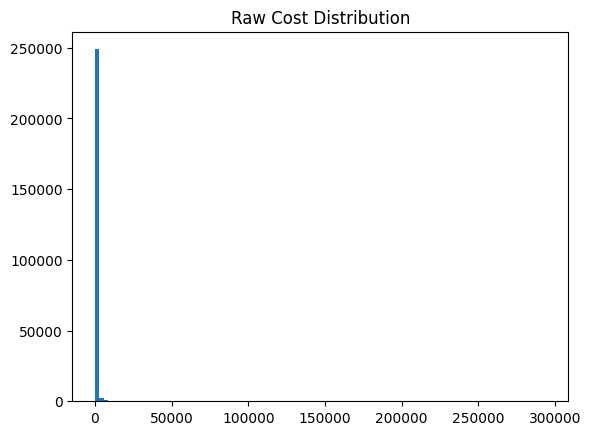

In [40]:
import matplotlib.pyplot as plt

plt.hist(reg_df["total_cost"], bins=100)
plt.title("Raw Cost Distribution")
plt.show()

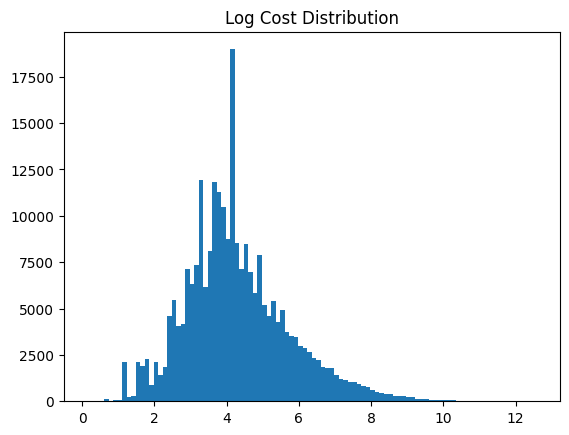

In [41]:
reg_df["log_cost"] = np.log1p(reg_df["total_cost"])

plt.hist(reg_df["log_cost"], bins=100)
plt.title("Log Cost Distribution")
plt.show()

In [42]:
X = reg_df["request_text"]
y = reg_df["log_cost"]

X_clean = X.apply(clean_text)
X_clean = X_clean.apply(add_keywords)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),  # simpler works better for regression
    min_df=10,
    max_df=0.8,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [51]:
upper_limit = reg_df["total_cost"].quantile(0.99)

reg_df = reg_df[reg_df["total_cost"] <= upper_limit]

In [52]:
def add_project_flag(text):
    project_terms = ["contract", "proposal", "invoice", "project", "bid"]
    
    if any(term in text for term in project_terms):
        return 1
    return 0

reg_df["is_project"] = reg_df["request_text"].apply(add_project_flag)

In [53]:
from sklearn.preprocessing import OneHotEncoder

trade_encoded = pd.get_dummies(reg_df["trade_clean"])

In [59]:
# Reset index
reg_df = reg_df.reset_index(drop=True)

# Create features
reg_df["text_length"] = reg_df["request_text"].str.len()

def add_project_flag(text):
    project_terms = ["contract", "proposal", "invoice", "project", "bid"]
    return int(any(term in str(text).lower() for term in project_terms))

reg_df["is_project"] = reg_df["request_text"].apply(add_project_flag)

# Prepare text
X = reg_df["request_text"]
y = reg_df["log_cost"]

X_clean = X.apply(clean_text)
X_clean = X_clean.apply(add_keywords)

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42
)

# Vectorize
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=10,
    max_df=0.8,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Structured features
from scipy.sparse import hstack

extra_features = reg_df.loc[X_train.index, ["text_length", "is_project"]]
extra_test = reg_df.loc[X_test.index, ["text_length", "is_project"]]

X_train_combined = hstack([X_train_vec, extra_features])
X_test_combined = hstack([X_test_vec, extra_test])

In [60]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train_vec, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test_vec)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE (log space):", mae)
print("RMSE (log space):", rmse)

MAE (log space): 0.7159974391233449
RMSE (log space): 0.9683530452980184


In [62]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("MAE (actual dollars):", mae_actual)
print("RMSE (actual dollars):", rmse_actual)

MAE (actual dollars): 143.64570932486774
RMSE (actual dollars): 413.7163644812251


In [65]:
results = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual_cost": y_test_actual.reset_index(drop=True),
    "predicted_cost": y_pred_actual
})

results["abs_error"] = (results["actual_cost"] - results["predicted_cost"]).abs()

display(results.sort_values("abs_error", ascending=False).head(10))

,text,actual_cost,predicted_cost,abs_error
13995,the doors all need to be cleaned varnished the...,4545.79,45.160298,4500.629702
45439,daily building checks and minor maintenance,4657.50,162.619479,4494.880521
33774,please re key all non assa doors on the second...,4665.68,183.917095,4481.762905
21989,purchase 45 chairs for mp208 and 25 chairs for...,4662.32,189.024719,4473.295281
38622,turf maintenance mowing,4691.70,246.310001,4445.389999
46090,please move all furniture and boxes out of a 3...,4525.34,81.619663,4443.720337
46611,hvac called in middle of the night for hvac hy...,4579.92,139.485688,4440.434312
7255,hardscape maintenance sweeping vacuuming parki...,4660.90,223.006997,4437.893003
48870,maint various amount of patching painting disa...,4568.50,161.919308,4406.580692
13116,daily building checks and minor maintenance,4540.60,162.619479,4377.980521
